<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab8/PL8_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prelab 8.3 Classifying Air-tight Vacuum and Air-leak Vacuum Data using Autoencoders for Anomaly Detection: Y and Z-axis

In [ ]:
# Let's check the installed tensorflow version
import tensorflow as tf

print('TensorFlow Version is', tf.__version__)

TensorFlow Version is 2.19.0


In [ ]:
# required Python packages for this colab
!pip install matplotlib
!pip install pandas
!pip install scipy
!pip install scikit-learn

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.fftpack
from tensorflow import keras

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

In [ ]:
# Copying raw data from github dataset file
url = 'https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab8/Prelab8_data.csv'
#df is the variable where the data is stored
df = pd.read_csv(url)

#Data selection
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
# If you want to use x-axis (X-axis),
# AXIS = 'Xacc array [m/s2]'
AXIS = 'Yacc array [m/s2]' #Pick and write the axis you want to work <-----------------------------------------------------------------------------

#Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1)
ds = df_new.copy()
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Vacuuming', 'Status'] = 1
ds.loc[df['Condition'] == 'Air_leakage', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

#Data transformation

raw_data = ds.values
# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the vacuum accelerometer data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)
#Normalizing the values of the dataset
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)
#Splitting the dataset based on classification: train_labels: Vacuuming, ~train_labels: Air Leakage
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

portion_of_anomaly_in_training = 0.1 #10% of training data will be anomalies
end_size = int(len(normal_train_data)/(10-portion_of_anomaly_in_training*10))
combined_train_data = np.append(normal_train_data, anomalous_test_data[:end_size], axis=0)
combined_train_data.shape

(536, 1000)

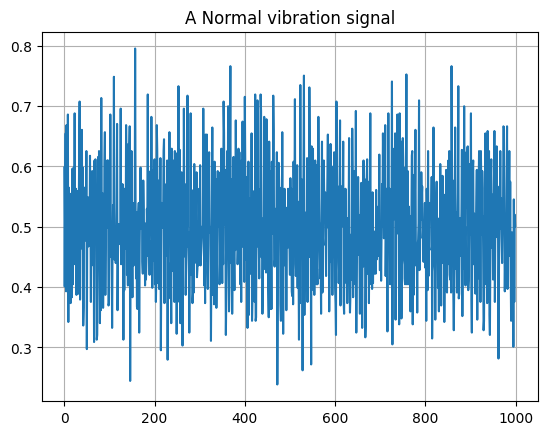

In [ ]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(1000), normal_train_data[0])
plt.title("A Normal vibration signal")
plt.show()

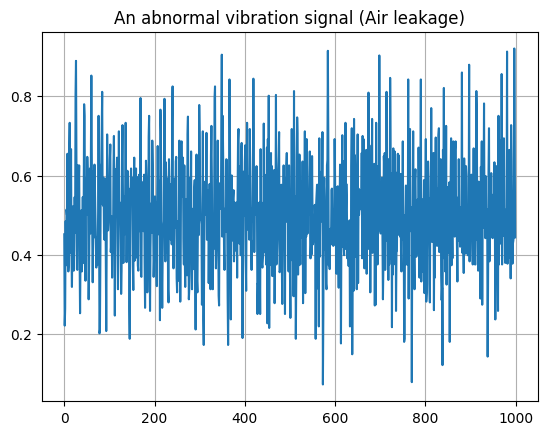

In [ ]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(1000), anomalous_train_data[0])
plt.title("An abnormal vibration signal (Air leakage)")
plt.show()

In [ ]:
#Creating the artificial neural network using Autoencoder
EMBEDDING_SIZE = 8  #Define how many neurons in the inner layer   <-----------------------------------------------------------------------------
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(32, activation="relu"),
      layers.Dense(16, activation="relu"),
      layers.Dense(EMBEDDING_SIZE, activation="relu")]) # Smallest Layer Defined Here

    self.decoder = tf.keras.Sequential([
      layers.Dense(16, activation="relu"),
      layers.Dense(32, activation="relu"),
      layers.Dense(1000, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()
print("Chosen Embedding Size: ", EMBEDDING_SIZE)

autoencoder.compile(optimizer='adam', loss='mae')
#Training the model.
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=200,
          batch_size=200,
          validation_data=(test_data, test_data),
          shuffle=True)

Chosen Embedding Size:  8
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - loss: 0.0739 - val_loss: 0.0916
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0736 - val_loss: 0.0916
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1

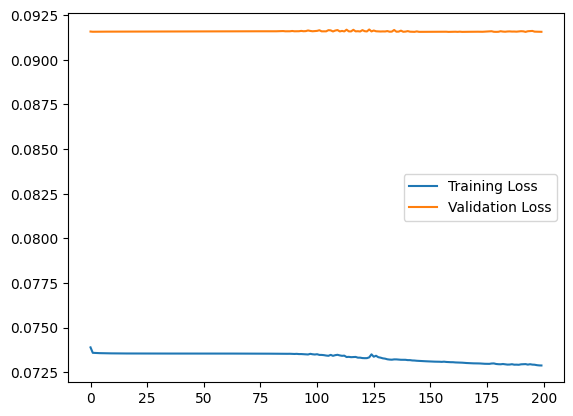

In [ ]:
#Plotting the evolution of training and validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

How are the loss functions looking? Is there a need to adjust the EMBEDDING SIZE or the epochs in order to minimize it more?

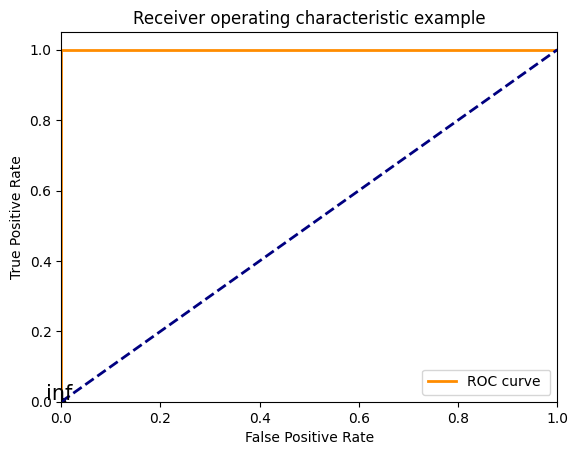

In [ ]:
#Plotting True positive and false positive rate assessment
reconstructions = autoencoder(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)
fpr = []
tpr = []
#the test labels are flipped to match how the roc_curve function expects them.
flipped_labels = 1-test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every=20
thresholdsLength = len(thresholds)
colorMap=plt.get_cmap('jet', thresholdsLength)
for i in range(0, thresholdsLength, thresholds_every):
  threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
  plt.scatter(fpr[i], tpr[i], c='black')
  plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15});

plt.show()

In [ ]:
roc_auc = auc(fpr, tpr)
print(roc_auc)

1.0


In [ ]:
threshold = 1.115 #Assign a value labeled in black in the ROC graph   <-----------------------------------------------------------------------------
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold), loss

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.4875
Precision = 0.4875
Recall = 1.0


### Task 3.1
How can you compare the models using data from the X-axis and Y-axis data? which one does a better job classifying? Explain your reasoning.



---

You can compare the models built from the X-axis and Y-axis data by looking at their evaluation metrics and plots, such as accuracy, precision, recall, validation loss, ROC curve, and AUC. The better model is the one that separates normal and abnormal data more clearly, has lower validation loss, and produces an ROC curve closer to the top-left corner with a higher AUC. You should also check whether one axis gives more stable results with fewer false positives and false negatives.

The axis that does a better job classifying is the one whose signal shows a clearer difference between normal and anomalous behavior.

---


##Working in the Z-axis

Recycle the code from the previous two dimensions, to build a model using the data from the Z-axis.

In [ ]:
#Your code here
# Copying raw data from github dataset file
url = 'https://raw.githubusercontent.com/purduelamm/purdue_me597_iiot/main/lab/lab8/Prelab8_data.csv'
#df is the variable where the data is stored
df = pd.read_csv(url)

#Data selection
# X-axis: 'Xacc array [m/s2]'
# Y-axis: 'Yacc array [m/s2]'
# Z-axis: 'Zacc array [m/s2]'
# If you want to use x-axis (X-axis),
# AXIS = 'Xacc array [m/s2]'
AXIS = 'Zacc array [m/s2]' #Pick and write the axis you want to work <-----------------------------------------------------------------------------

#Exploding the values contained in selected column and converting the string values into float values
df_new = pd.concat([df['Condition'],df[AXIS].str.split(' ', expand=True).astype(float)], axis=1)
ds = df_new.copy()
#Converting the Classifier into binary values
ds.loc[df['Condition'] == 'Vacuuming', 'Status'] = 1
ds.loc[df['Condition'] == 'Air_leakage', 'Status'] = 0
ds.drop('Condition', axis=1, inplace=True)

#Data transformation

raw_data = ds.values
# The last element contains the labels
labels = raw_data[:, -1]

# The other data points are the vacuum accelerometer data
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)
#Normalizing the values of the dataset
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)
#Splitting the dataset based on classification: train_labels: Vacuuming, ~train_labels: Air Leakage
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

portion_of_anomaly_in_training = 0.1 #10% of training data will be anomalies
end_size = int(len(normal_train_data)/(10-portion_of_anomaly_in_training*10))
combined_train_data = np.append(normal_train_data, anomalous_test_data[:end_size], axis=0)
combined_train_data.shape
#

(536, 1000)

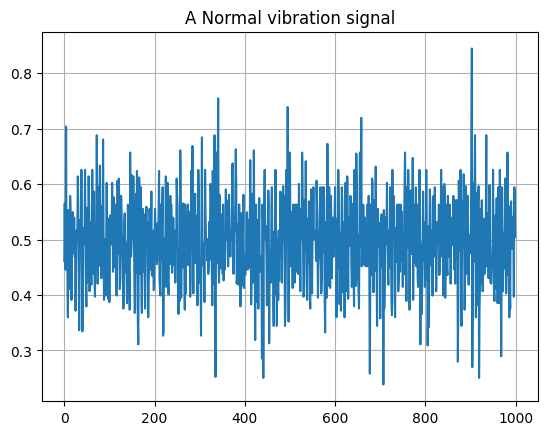

In [ ]:
#Plotting sample of normal data
plt.grid()
plt.plot(np.arange(1000), normal_train_data[0])
plt.title("A Normal vibration signal")
plt.show()

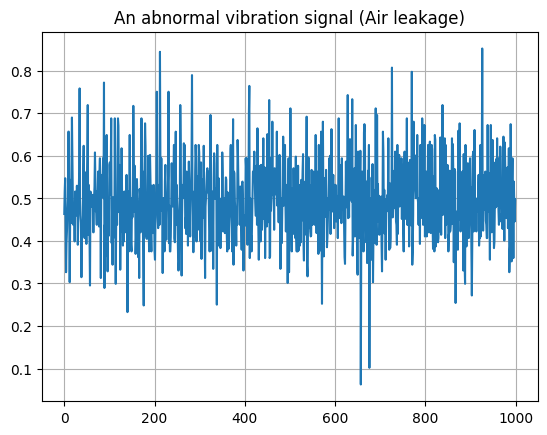

In [ ]:
#Plotting sample of anomalous data
plt.grid()
plt.plot(np.arange(1000), anomalous_train_data[0])
plt.title("An abnormal vibration signal (Air leakage)")
plt.show()

In [ ]:
#Creating the artificial neural network using Autoencoder
EMBEDDING_SIZE = 8  #Define how many neurons in the inner layer   <-----------------------------------------------------------------------------
class AnomalyDetector(Model):
  def __init__(self):
    super(AnomalyDetector, self).__init__()
    self.encoder = tf.keras.Sequential([
      layers.Dense(32, activation="relu"),
      layers.Dense(16, activation="relu"),
      layers.Dense(EMBEDDING_SIZE, activation="relu")]) # Smallest Layer Defined Here

    self.decoder = tf.keras.Sequential([
      layers.Dense(16, activation="relu"),
      layers.Dense(32, activation="relu"),
      layers.Dense(1000, activation="sigmoid")])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded

autoencoder = AnomalyDetector()
print("Chosen Embedding Size: ", EMBEDDING_SIZE)

autoencoder.compile(optimizer='adam', loss='mae')
#Training the model.
history = autoencoder.fit(normal_train_data, normal_train_data,
          epochs=200,
          batch_size=200,
          validation_data=(test_data, test_data),
          shuffle=True)

Chosen Embedding Size:  8
Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - loss: 0.0619 - val_loss: 0.0655
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0615 - val_loss: 0.0655
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 10/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 11/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0615 - val_loss: 0.0656
Epoch 12/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/s

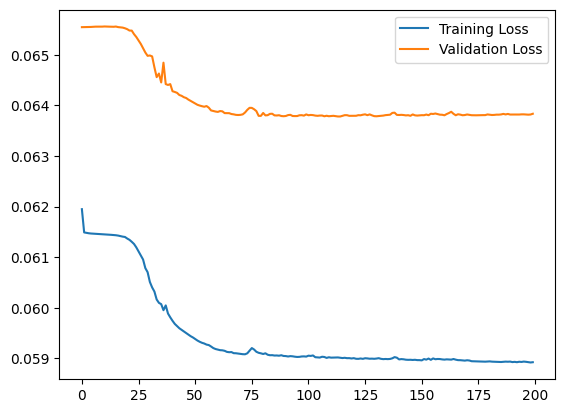

In [ ]:
#Plotting the evolution of training and validation loss
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()

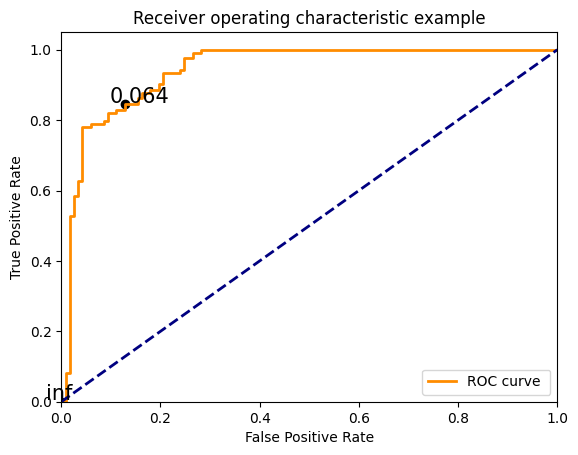

In [ ]:
#Plotting True positive and false positive rate assessment
reconstructions = autoencoder(test_data)
loss = tf.keras.losses.mae(reconstructions, test_data)
fpr = []
tpr = []
#the test labels are flipped to match how the roc_curve function expects them.
flipped_labels = 1-test_labels
fpr, tpr, thresholds = roc_curve(flipped_labels, loss)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange',
         lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")

# plot some thresholds
thresholds_every=20
thresholdsLength = len(thresholds)
colorMap=plt.get_cmap('jet', thresholdsLength)
for i in range(0, thresholdsLength, thresholds_every):
  threshold_value_with_max_four_decimals = str(thresholds[i])[:5]
  plt.scatter(fpr[i], tpr[i], c='black')
  plt.text(fpr[i] - 0.03, tpr[i] + 0.005, threshold_value_with_max_four_decimals, fontdict={'size': 15});

plt.show()

In [ ]:
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.9426725036481134


In [ ]:
threshold = 0.064 #Assign a value labeled in black in the ROC graph   <-----------------------------------------------------------------------------
def predict(model, data, threshold):
  reconstructions = model(data)
  loss = tf.keras.losses.mae(reconstructions, data)
  return tf.math.less(loss, threshold), loss

def print_stats(predictions, labels):
  print("Accuracy = {}".format(accuracy_score(labels, predictions)))
  print("Precision = {}".format(precision_score(labels, predictions)))
  print("Recall = {}".format(recall_score(labels, predictions)))

preds, scores = predict(autoencoder, test_data, threshold)
print_stats(preds, test_labels)

Accuracy = 0.8458333333333333
Precision = 0.8389830508474576
Recall = 0.8461538461538461


### Task 3.2
Which model (X, Y, or Z) would you choose to classify normal and abnormal readings for the vacuum problem? Explain your reasoning.



---

The Z-axis model performs better for classifying normal and abnormal readings. This is because the Z-axis shows a consistent decrease in both training and validation loss, with a small gap between them, indicating good generalization. In contrast, the Y-axis model has higher validation loss and minimal improvement during training, which suggests underfitting and poor pattern learning. Therefore, the Z-axis captures the vibration differences between normal and abnormal conditions more effectively, making it the better choice for classification.

---


### Task 3.3
What other data transformations/extractions would you consider to build a model to classify normal and abnormal data on the vacuum problem?



---

I would use statistical features like mean, standard deviation, RMS, and max/min to summarize the signal. I would also extract frequency features (FFT) since anomalies often show up in vibration frequencies. Using sliding windows can help capture local changes, and combining X, Y, Z axes can improve detection. Additionally, applying noise filtering and normalization can make the model more accurate.

---


<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)